<a href="https://colab.research.google.com/github/asiddiqha/ml-practice-notebooks/blob/main/neural_network_classification_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Models: Classification & Regression

**Projects**
1. Student performance classification — Low / Medium / High
2. House price regression — predicting price in lakhs

The workflow covers data quality checks, focused EDA, preprocessing, neural-network modelling, evaluation, and a small prediction example.


## 1. Imports & plotting setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.initializers import HeNormal

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Soft pastel colours for EDA
PASTEL = sns.color_palette("pastel")
sns.set_theme(style="whitegrid", palette="pastel")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14


# Part A — Student Performance Classification

The target is `performance`, with three classes: **Low, Medium and High**.

In [2]:
df = pd.read_csv("student_multiclass_neural_network_dataset.csv")
df.head()


,study_hours,attendance,assignment_score,exam_score,sleep_hours,participation_score,performance
0,6.29,83.18,88.16,35.34,5.19,60.00,Medium
1,3.10,99.83,79.66,83.15,4.48,32.36,Medium
2,4.27,74.79,71.75,76.27,8.04,25.41,Medium
3,1.46,69.43,80.86,93.12,7.47,66.14,Low
4,3.80,78.83,49.60,35.29,5.04,27.02,Low


## 2. Data quality checks

Before modelling, I want to know the dataset size, data types, missing values and duplicate rows.

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing"))

print(f"Duplicate rows: {df.duplicated().sum()}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Rows: 900
Columns: 7

Missing values:


,missing
study_hours,0
attendance,0
assignment_score,0
exam_score,0
sleep_hours,0
participation_score,0
performance,0


Duplicate rows: 0

Data types:


,dtype
study_hours,float64
attendance,float64
assignment_score,float64
exam_score,float64
sleep_hours,float64
participation_score,float64
performance,object


## 3. Summary statistics

In [4]:
display(df.describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
study_hours,900.0,4.19,2.20,0.53,2.23,4.26,6.11,8.00
attendance,900.0,75.13,14.65,50.25,61.92,75.62,87.77,99.97
assignment_score,900.0,67.50,18.58,35.01,52.56,67.77,83.63,99.89
exam_score,900.0,65.11,20.23,30.00,47.42,65.40,82.52,99.92
sleep_hours,900.0,6.43,1.43,4.00,5.17,6.39,7.64,9.00
participation_score,900.0,59.96,23.08,20.02,40.42,58.81,80.22,99.90


## 4. Target distribution

This is significant for a multiclass issue since a severely unbalanced target might make accuracy deceptive.

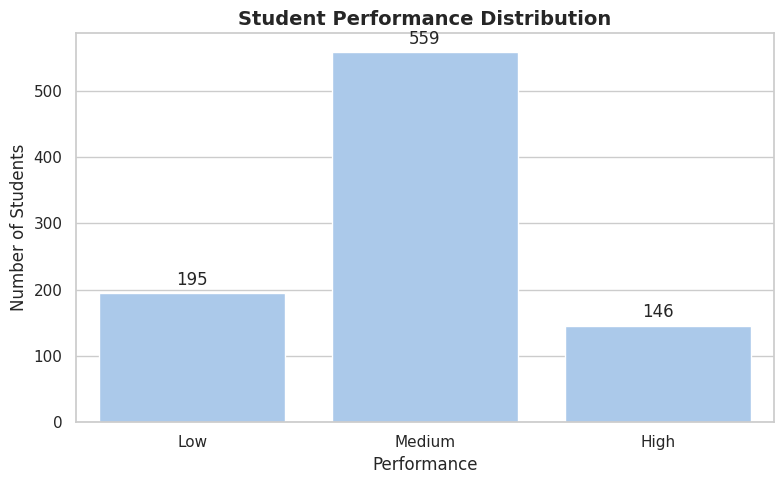

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="performance", order=["Low", "Medium", "High"])

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Student Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


## 5. Feature distributions

Before scaling, a glance at the numerical variables to find any outliers or skewed distributions.

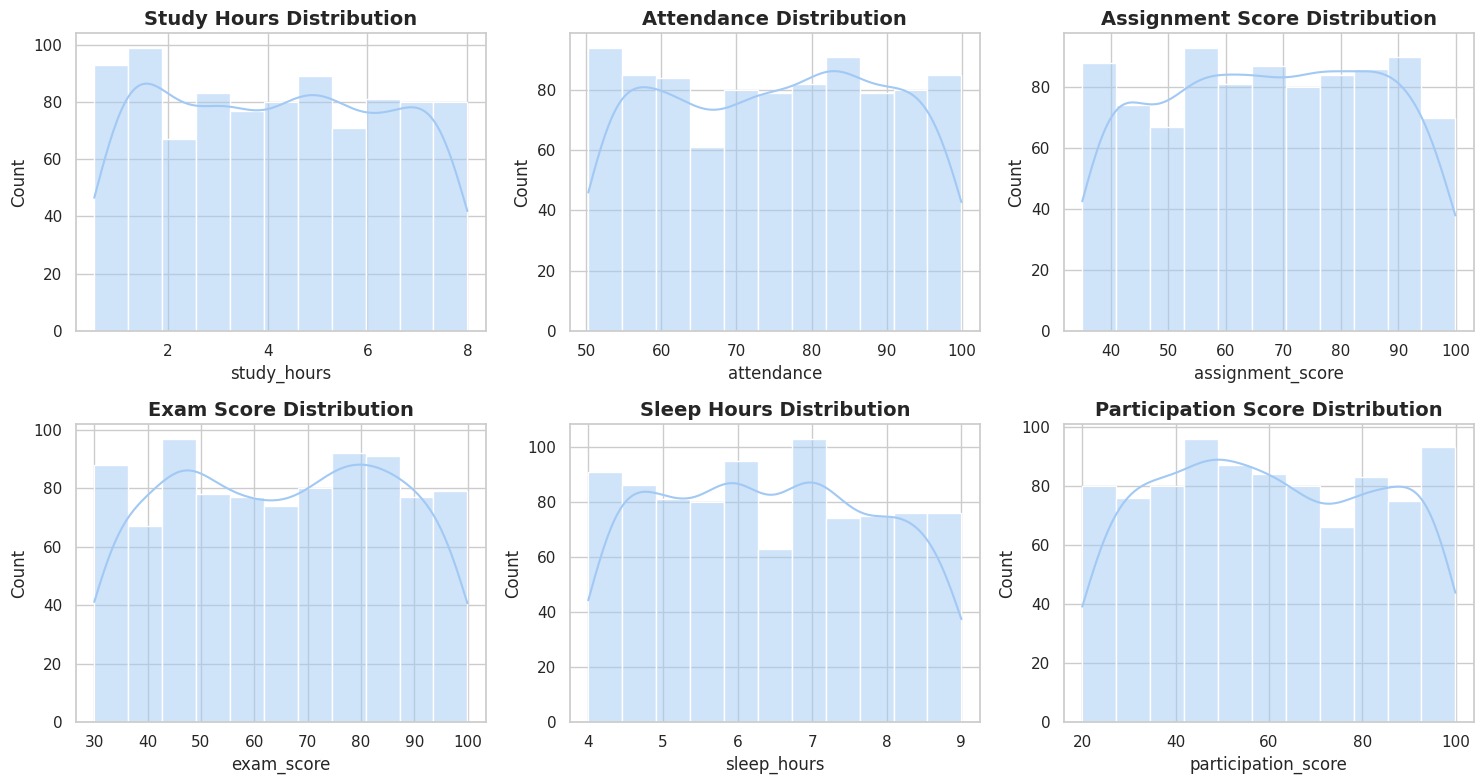

In [6]:
numeric_cols = df.select_dtypes(include="number").columns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color=PASTEL[0])
    ax.set_title(f"{col.replace('_', ' ').title()} Distribution")

plt.tight_layout()
plt.show()


## 6. Outlier check with boxplots

Instead of automatically eliminating observations, boxplots is used for a fast visual inspection.

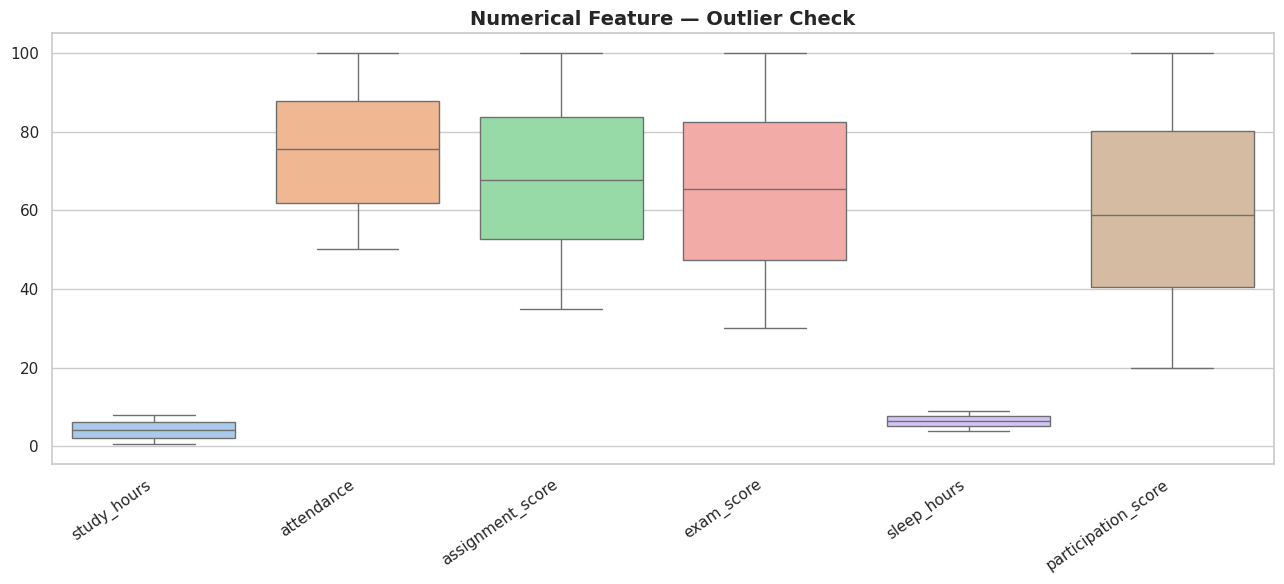

In [7]:
plt.figure(figsize=(13, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Numerical Feature — Outlier Check")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 7. Correlation between numerical variables

Correlation identifies factors that move together. It is not sufficient to demonstrate causality.

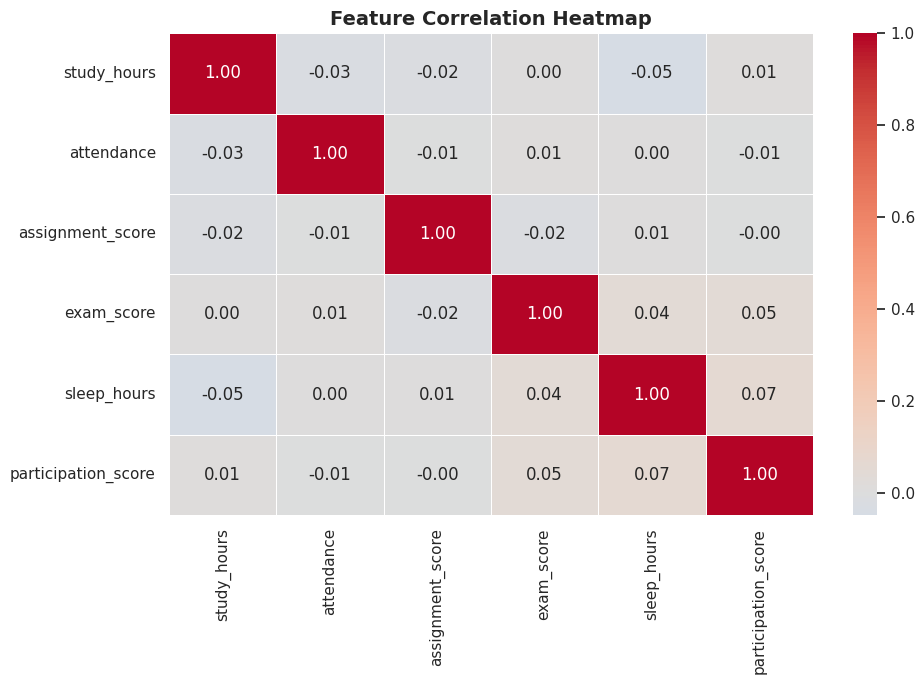

In [8]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 8. Pairplot

This gives a compact view of pairwise relationships and distributions across the numerical features.

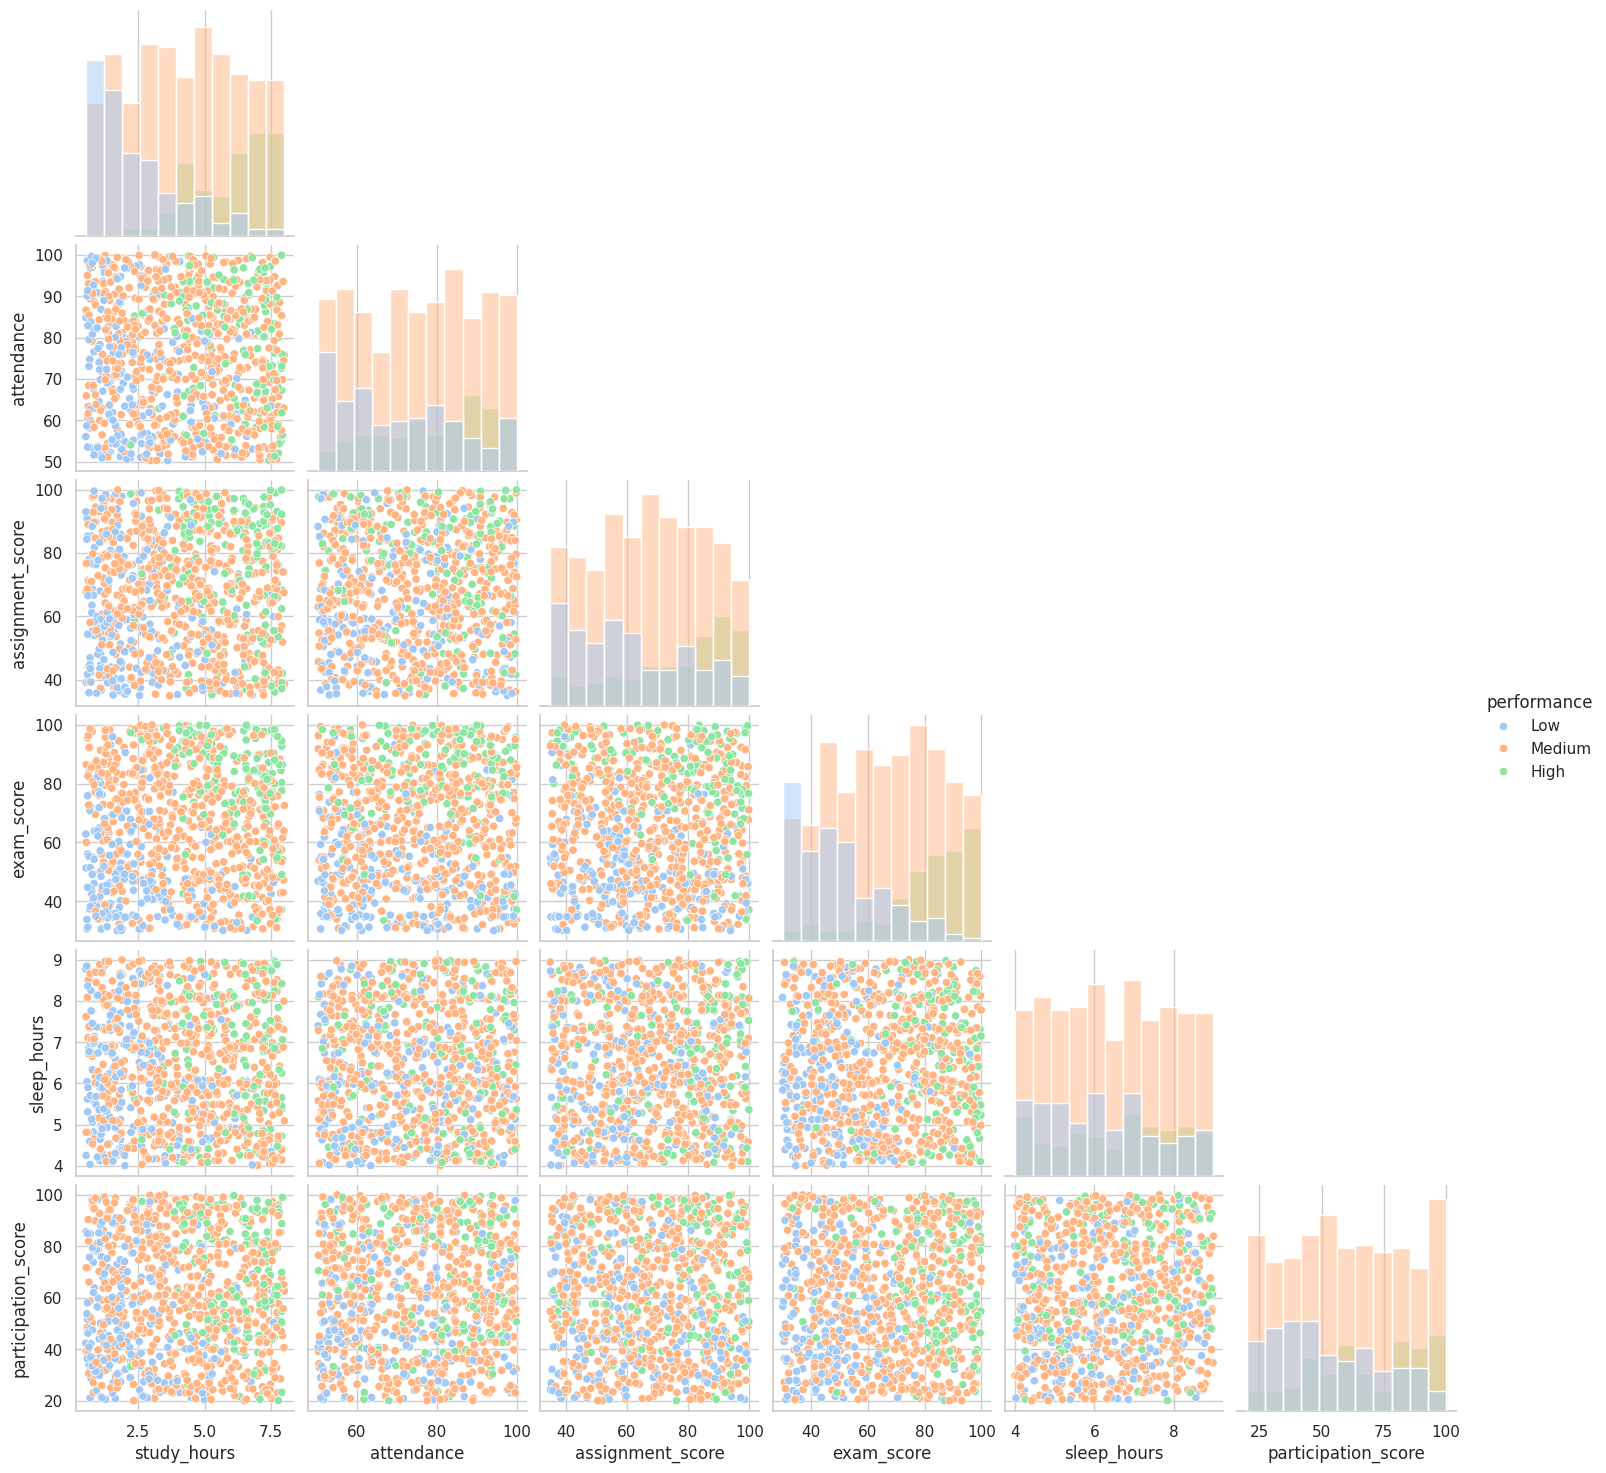

In [9]:
sns.pairplot(
    df,
    vars=numeric_cols,
    hue="performance",
    hue_order=["Low", "Medium", "High"],
    palette="pastel",
    corner=True,
    diag_kind="hist",
)
plt.show()


## 9. Prepare the classification data

The text labels are mapped to numeric class IDs because the model uses `sparse_categorical_crossentropy`.

In [10]:
X = df.drop(columns="performance")
y = df["performance"]

label_mapping = {"Low": 0, "Medium": 1, "High": 2}
class_names = ["Low", "Medium", "High"]

y = y.map(label_mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Training samples: 720
Test samples: 180


## 10. Standardize the features

The scaler is fitted **only on the training set**. This avoids leaking information from the test set into training.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 11. Build the classification neural network

There are six input features, two hidden layers, and three output neurons — one for each performance class.

In [12]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu", kernel_initializer=HeNormal()),
    Dense(8, activation="relu", kernel_initializer=HeNormal()),
    Dense(3, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.07 KB)

 Trainable params: 275 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Train the classification model

50 epochs gives the model enough opportunity to learn. The validation split lets us monitor performance on data not used for weight updates.

In [13]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1,
)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4097 - loss: 1.1219 - val_accuracy: 0.3958 - val_loss: 1.1050
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5260 - loss: 1.0181 - val_accuracy: 0.5486 - val_loss: 1.0339
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6059 - loss: 0.9553 - val_accuracy: 0.5833 - val_loss: 0.9927
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6198 - loss: 0.9175 - val_accuracy: 0.5764 - val_loss: 0.9662
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6198 - loss: 0.8918 - val_accuracy: 0.5694 - val_loss: 0.9469
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6302 - loss: 0.8710 - val_accuracy: 0.5694 - val_loss: 0.9305
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6337 - loss: 0.8523 - val_accuracy: 0.5694 - val_loss: 0.9156
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6354 - loss: 0.8340 - val_accuracy: 0.5694 - val_loss

## 13. Training vs validation performance

The validation curves are particularly useful for checking whether additional training is improving generalization or beginning to overfit.

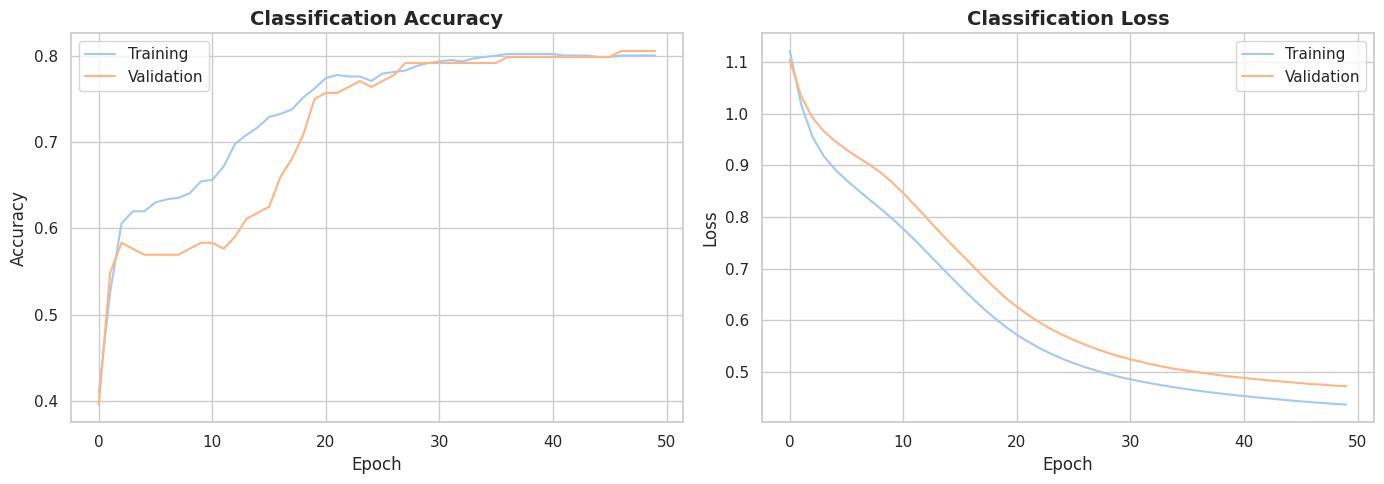

In [14]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["accuracy"], label="Training")
axes[0].plot(history_df["val_accuracy"], label="Validation")
axes[0].set_title("Classification Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_df["loss"], label="Training")
axes[1].plot(history_df["val_loss"], label="Validation")
axes[1].set_title("Classification Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## 14. Evaluate on the test set

The test set is kept separate until this point, giving us an estimate of performance on unseen observations.

In [15]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0,
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Loss: 0.5191
Test Accuracy: 76.67%


## 15. Classification report & confusion matrix

Accuracy gives one overall number. Precision, recall and F1-score show how the model behaves for each class.

              precision    recall  f1-score   support

         Low       0.83      0.64      0.72        39
      Medium       0.80      0.84      0.82       112
        High       0.59      0.66      0.62        29

    accuracy                           0.77       180
   macro avg       0.74      0.71      0.72       180
weighted avg       0.77      0.77      0.77       180



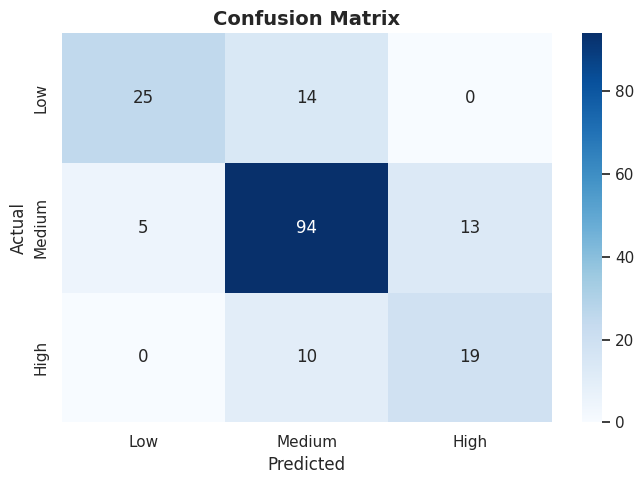

In [16]:
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=2,
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 16. Predict performance for a new student

Using a DataFrame preserves the original feature names and avoids the `StandardScaler` feature-name warning.

In [17]:
new_student = pd.DataFrame([{
    "study_hours": 6.0,
    "attendance": 90.0,
    "assignment_score": 85.0,
    "exam_score": 88.0,
    "sleep_hours": 7.0,
    "participation_score": 80.0,
}])

new_student_scaled = scaler.transform(new_student)

prediction_proba = model.predict(new_student_scaled, verbose=0)
predicted_class = np.argmax(prediction_proba, axis=1)[0]

print(f"Predicted Performance: {class_names[predicted_class]}")
print("Class probabilities:")

display(pd.DataFrame(
    [prediction_proba[0]],
    columns=class_names,
).round(3))


Predicted Performance: High
Class probabilities:


,Low,Medium,High
0,0.001,0.094,0.906


# Part B — House Price Regression

This model predicts `price_lakhs` from six numerical property features.

In [18]:
df_reg = pd.read_csv("house_price_regression_neural_network_dataset.csv")
df_reg.head()


,area_sqft,bedrooms,bathrooms,age_years,distance_city_km,parking_spaces,price_lakhs
0,1643,2,2,28.6,1.9,3,131.70
1,2950,2,1,2.5,19.8,2,192.62
2,1888,5,2,2.2,5.1,2,150.72
3,1568,5,4,3.9,10.9,2,153.84
4,3350,4,1,1.2,9.5,3,218.61


## 17. Regression data quality checks

In [19]:
print(f"Rows: {df_reg.shape[0]:,}")
print(f"Columns: {df_reg.shape[1]}")

print("\nMissing values:")
display(df_reg.isnull().sum().to_frame("missing"))

print(f"Duplicate rows: {df_reg.duplicated().sum()}")

display(df_reg.describe().T.round(2))


Rows: 1,000
Columns: 7

Missing values:


,missing
area_sqft,0
bedrooms,0
bathrooms,0
age_years,0
distance_city_km,0
parking_spaces,0
price_lakhs,0


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
area_sqft,1000.0,1970.78,876.42,514.00,1208.25,1990.50,2733.00,3499.00
bedrooms,1000.0,3.04,1.43,1.00,2.00,3.00,4.00,5.00
bathrooms,1000.0,2.55,1.13,1.00,2.00,3.00,4.00,4.00
age_years,1000.0,15.46,8.55,0.00,8.10,15.90,22.90,30.00
distance_city_km,1000.0,15.50,8.38,1.00,8.30,15.65,22.82,29.90
parking_spaces,1000.0,1.48,1.10,0.00,1.00,2.00,2.00,3.00
price_lakhs,1000.0,129.72,50.86,19.09,87.24,130.16,170.90,258.58


## 18. Regression EDA — target distribution

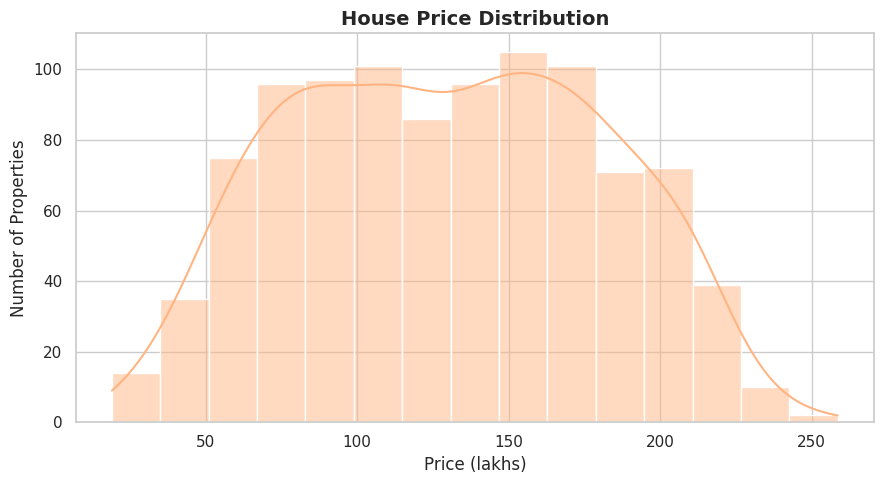

In [20]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df_reg,
    x="price_lakhs",
    kde=True,
    color=PASTEL[1],
)
plt.title("House Price Distribution")
plt.xlabel("Price (lakhs)")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()


## 19. Regression feature relationships

The scatterplots provide a quick view of how each property feature relates to price.

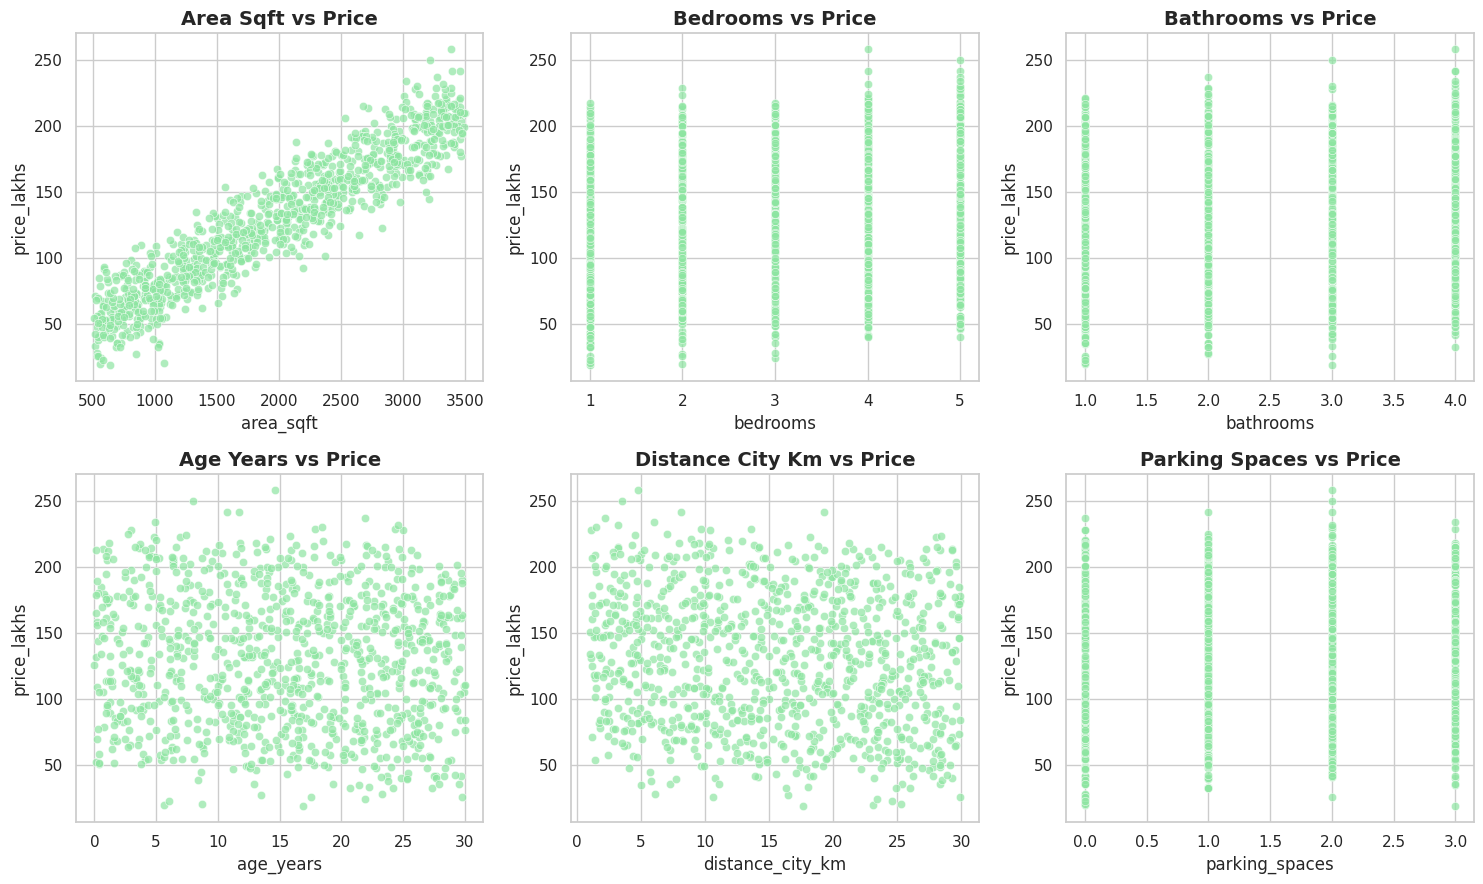

In [21]:
feature_cols_reg = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "age_years",
    "distance_city_km",
    "parking_spaces",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols_reg):
    sns.scatterplot(
        data=df_reg,
        x=col,
        y="price_lakhs",
        ax=ax,
        alpha=0.7,
        color=PASTEL[2],
    )
    ax.set_title(f"{col.replace('_', ' ').title()} vs Price")

plt.tight_layout()
plt.show()


## 20. Regression correlation heatmap

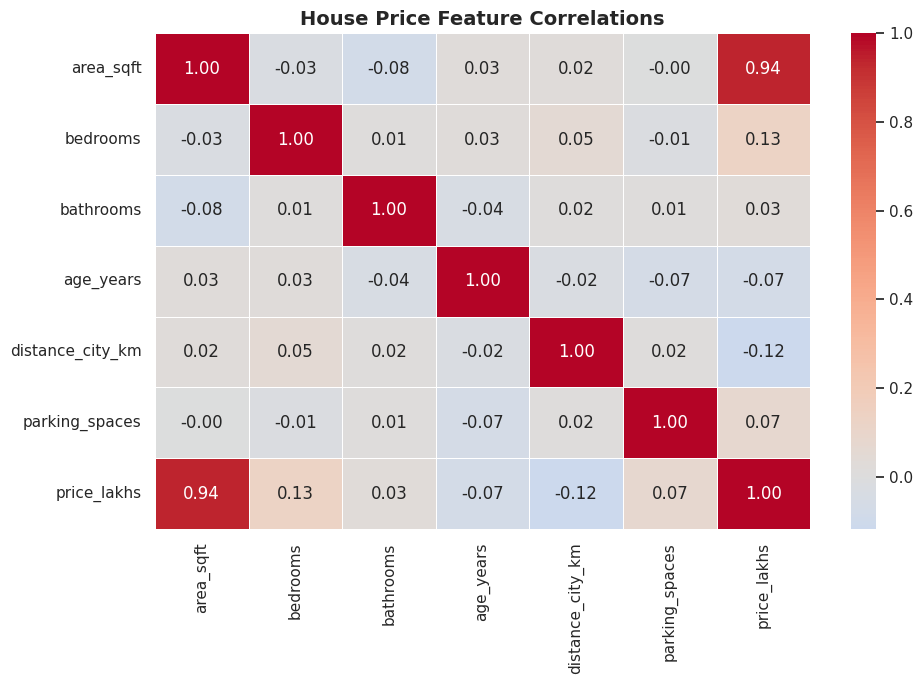

In [22]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df_reg.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("House Price Feature Correlations")
plt.tight_layout()
plt.show()


## 21. Prepare regression data

In [23]:
X_reg = df_reg.drop(columns="price_lakhs")
y_reg = df_reg["price_lakhs"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42,
)

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f"Training samples: {len(X_train_reg)}")
print(f"Test samples: {len(X_test_reg)}")


Training samples: 800
Test samples: 200


## 22. Build the regression neural network

Unlike classification, regression needs a single numerical output neuron. No activation is used on the final layer so the network can predict a continuous value.

In [24]:
model_reg = Sequential([
    Input(shape=(X_train_reg_scaled.shape[1],)),
    Dense(16, activation="relu", kernel_initializer=HeNormal()),
    Dense(8, activation="relu", kernel_initializer=HeNormal()),
    Dense(1),
])

model_reg.compile(
    optimizer="adam",
    loss="mean_squared_error",
)

model_reg.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

## 23. Train the regression model

In [25]:
history_reg = model_reg.fit(
    X_train_reg_scaled,
    y_train_reg,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1,
)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 19848.0293 - val_loss: 20487.9629
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19685.7559 - val_loss: 20340.8906
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19551.7617 - val_loss: 20219.4688
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19437.6641 - val_loss: 20115.9180
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19337.6855 - val_loss: 20022.7188
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19246.0352 - val_loss: 19934.5078
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19157.1699 - val_loss: 19846.8320
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19067.5723 - val_loss: 19755.9160
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18973.8594 - val_loss: 19659.1719
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18872.9727 - val_loss: 19554.0566
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18762.4629 - val_lo

## 24. Regression learning curve

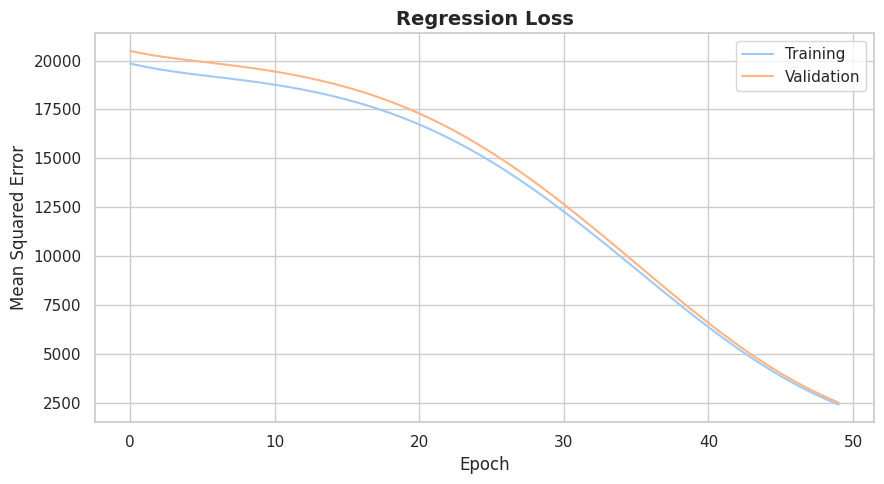

In [26]:
history_reg_df = pd.DataFrame(history_reg.history)

plt.figure(figsize=(9, 5))
plt.plot(history_reg_df["loss"], label="Training")
plt.plot(history_reg_df["val_loss"], label="Validation")
plt.title("Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.tight_layout()
plt.show()


## 25. Evaluate the regression model

MSE is useful during training, but MAE and RMSE are easier to interpret in the target's original unit. R² gives a complementary measure of explained variance.

In [27]:
test_mse = model_reg.evaluate(
    X_test_reg_scaled,
    y_test_reg,
    verbose=0,
)

y_pred_reg = model_reg.predict(
    X_test_reg_scaled,
    verbose=0,
).ravel()

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Test MSE:  {test_mse:.2f}")
print(f"Test MAE:  {mae:.2f} lakhs")
print(f"Test RMSE: {rmse:.2f} lakhs")
print(f"Test R²:   {r2:.3f}")


Test MSE:  2460.67
Test MAE:  43.14 lakhs
Test RMSE: 49.61 lakhs
Test R²:   -0.013


## 26. Actual vs predicted prices

Points closer to the diagonal represent predictions that are closer to the actual house prices.

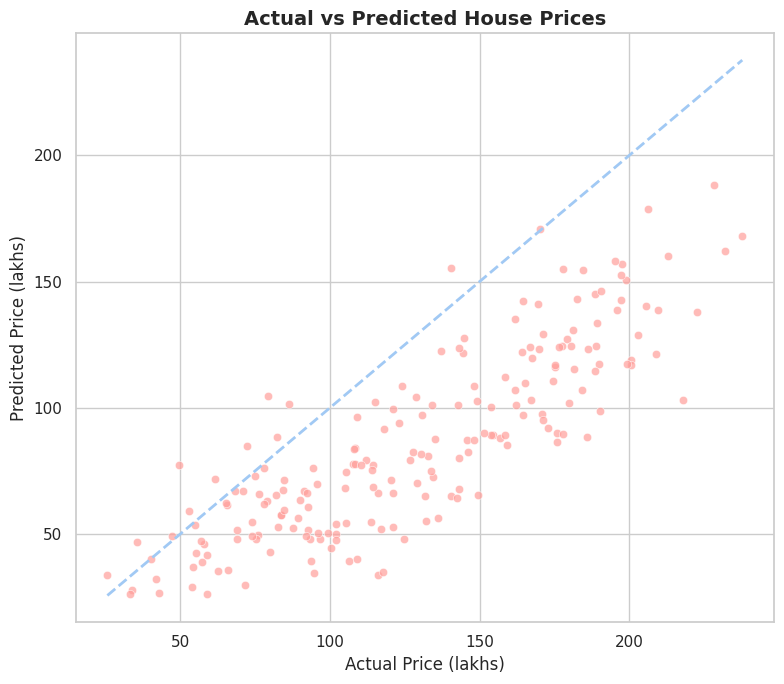

In [28]:
plt.figure(figsize=(8, 7))

sns.scatterplot(
    x=y_test_reg,
    y=y_pred_reg,
    alpha=0.7,
    color=PASTEL[3],
)

min_value = min(y_test_reg.min(), y_pred_reg.min())
max_value = max(y_test_reg.max(), y_pred_reg.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price (lakhs)")
plt.ylabel("Predicted Price (lakhs)")
plt.tight_layout()
plt.show()


# Final Takeaways

### Student performance classification
- Six numerical student features are standardized before training.
- The neural network uses two hidden layers and a three-class softmax output.
- Accuracy is supplemented with a class-level classification report and confusion matrix.

### House price regression
- Six property features are standardized before training.
- The network ends with one continuous output.
- MAE, RMSE and R² provide more useful evaluation context than MSE alone.

### Reproducibility
- Random seeds are set for NumPy and TensorFlow.
- The test set remains separate from model fitting and is used only for final evaluation.
